In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

import dask

from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 


# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

# dask
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

Number of CPUs: 256, number of threads: 8, number of workers: 32


/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45085 instead
  warnings.warn(


In [2]:
import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import seaborn as sns
import pandas as pd
import xarray as xr
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm

import cartopy as cartopy

In [4]:
!pip install -U easygems  # install modules

In [5]:
pip install dask_jobqueue

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import easygems.healpix as egh

In [4]:
import sys
sys.path.append('/work/mh0731/m300876/package')
import icons

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

In [6]:
def plot_map(da, ax=None, title=None, colorbar=True, cmap="viridis", nest=True, vmin=None, vmax=None, levels=None, latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    if not ax:
        projection = ccrs.PlateCarree(central_longitude=225)
        fig, ax = plt.subplots(
            subplot_kw={"projection": projection}, constrained_layout=True
        )
    ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(title)
    
    # Use the range values if provided
    norm = None
    if vmin is not None and vmax is not None:
        norm = plt.Normalize(vmin, vmax)

    pc = egh.healpix_show(da, ax=ax, cmap=cmap, norm=norm, nest=nest)
    
    if colorbar:
        cbar = fig.colorbar(pc, ax=ax, orientation="horizontal", aspect=50)
        if levels is not None:
            cbar.set_ticks(levels)
    return pc

# Load datasets

_AMIP_

In [4]:
# ICON CTL (5km)
import intake
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1981

In [8]:
data_p4k  = cat['ICON.C5.AMIP_P4K'](time="P1D", zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1981

In [9]:
data_4co2 = cat['ICON.C5.AMIP_4CO2'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1980-1994

_AMIP_

In [6]:
# ICON CTL
dx_ngc = cat.ICON.ngc4008(zoom=9).to_dask().pipe(egh.attach_coords)
dx_ngc_start = dx_ngc.sel(time=slice('2024-01-01', '2028-12-31')) # 5 years
dx_ngc_end = dx_ngc.sel(time=slice('2045-01-01', '2049-12-31')) # 5years

_IFS_

In [11]:
dx_ifs = cat.IFS['IFS_9-FESOM_5-production']['2D_monthly_healpix512'].to_dask() #.pipe(egh.attach_coords)
dx_ifs_start = dx_ifs.sel(time=slice('2024-01-01', '2028-12-31')) # 5 years
dx_ifs_end = dx_ifs.sel(time=slice('2045-01-01', '2049-12-31')) # 5years

**Masking land**

In [14]:
# Land
def land(ds):
    return ds.where(ds.cell_sea_land_mask == 2)

In [15]:
pr_ctl = land(data_ctl)
pr_p4k = land(data_p4k)
pr_4co2 = land(data_4co2)

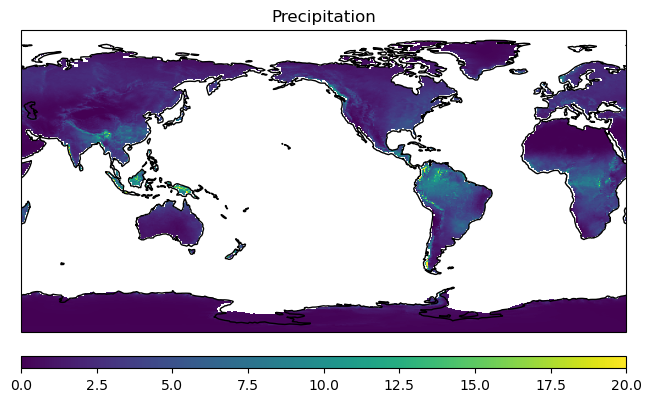

In [141]:
plot_map(pr_ctl.pr.sel(time=slice('1979-01-02', '1981-12-31')).mean(dim='time') * 86400, title="Precipitation", cmap="viridis", vmin=0, vmax=20)

In [7]:
data_ctl.pr

<xarray.DataArray 'pr' (time: 6756, cell: 786432)> Size: 21GB
dask.array<concatenate, shape=(6756, 786432), dtype=float32, chunksize=(366, 81920), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 54kB 1979-01-02 1979-01-03 ... 1997-07-01
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    healpix  int64 8B 0
Attributes:
    standard_name:  pr
    long_name:      precipitation flux
    units:          kg m-2 s-1
    param:          52.1.0
    grid_mapping:   healpix

In [16]:
def land2(ds):
    return ds.where(ds.ocean_fraction_surface == 0)

In [17]:
ngc4008_begin = land2(ngc4008_begin)
ngc4008_end = land2(ngc4008_end)

**Convert latitude from 0-360 to -180-180**

In [21]:
xarray_names = ['data_ctl','data_p4k','data_4co2','dx_ngc_start','dx_ngc_end']

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_lon = xarray_data.pr.assign_coords(
        lon=((xarray_data.lon + 180) % 360 - 180)
    ) # convert the longitude from 0-360 to -180-180
    
    xarray_data_cropped = xarray_data_lon.where(
        (xarray_data_lon.lat > -30) & (xarray_data_lon.lat < 13) & 
        (xarray_data_lon.lon > -82) & (xarray_data_lon.lon < -30), 
        drop=True
    ) # crop the region
    
    xarray_data_cropped_pr = xarray_data_cropped * 86400 # convert from m/s to mm/day

    new_name = name + '_crop_pr'
        
    globals()[new_name] = xarray_data_cropped_pr

In [ ]:
xarray_names = ['dx_ifs_start','dx_ifs_end']

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_lon = xarray_data.tp.assign_coords(
        lon=((xarray_data.lon + 180) % 360 - 180)
    ) # convert the longitude from 0-360 to -180-180
    
    xarray_data_cropped = xarray_data_lon.where(
        (xarray_data_lon.lat > -30) & (xarray_data_lon.lat < 13) & 
        (xarray_data_lon.lon > -82) & (xarray_data_lon.lon < -30), 
        drop=True
    ) # crop the region
    
    xarray_data_cropped_pr = xarray_data_cropped * 1000 # convert from m/s to mm/day

    new_name = name + '_crop_pr'
        
    globals()[new_name] = xarray_data_cropped_pr

**Monthly mean**

In [19]:
# collect month for each year - for calculation standard deviation (std for each month - multiple years)
def mon_mean(x):
    return x.groupby('time.month').mean('time')

In [20]:
# avgerage three years mean over month
pr_ctl_crop_month = pr_ctl_crop_pr.groupby('time.month').mean('time')
pr_p4k_crop_month = pr_p4k_crop_pr.groupby('time.month').mean('time')
pr_4co2_crop_month = pr_4co2_crop_pr.groupby('time.month').mean('time')
pr_ngcb_crop_month = ngc4008_begin_crop_pr.groupby('time.month').mean('time')
pr_ngce_crop_month = ngc4008_end_crop_pr.groupby('time.month').mean('time')

In [21]:
pr_ctl_crop_q90 =pr_ctl_crop_month.chunk({'cell': -1}).quantile(0.90, dim='cell')
pr_p4k_crop_q90 =pr_p4k_crop_month.chunk({'cell': -1}).quantile(0.90, dim='cell')
pr_4co2_crop_q90 =pr_4co2_crop_month.chunk({'cell': -1}).quantile(0.90, dim='cell')
pr_ngcb_crop_q90 =pr_ngcb_crop_month.chunk({'cell': -1}).quantile(0.90, dim='cell')
pr_ngce_crop_q90 =pr_ngce_crop_month.chunk({'cell': -1}).quantile(0.90, dim='cell')

In [26]:
pr_ctl_crop_q90[0].values

array(12.07137669)

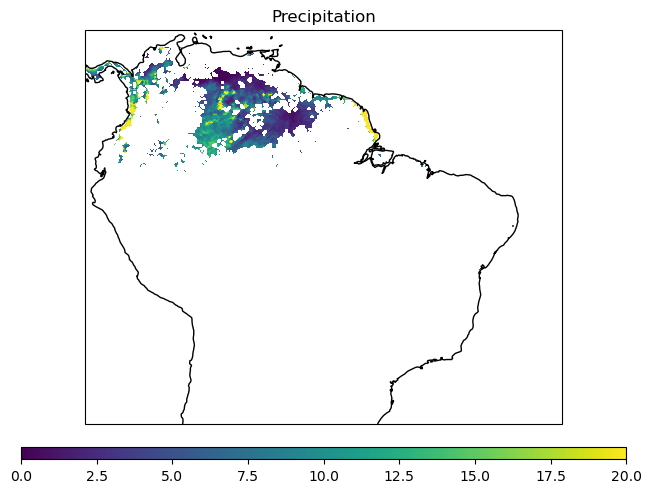

In [28]:
plot_map(pr_ctl_crop_month.isel(month=11).where(pr_ctl_crop_month.isel(month=6) > pr_ctl_crop_q90.isel(month=6)), title="Precipitation", cmap="viridis", vmin=0, vmax=20, latmin=-30, latmax=13, lonmin=-82, lonmax=-30)

# Calculate the object

## calculate object detection

_calculate area grid_

In [12]:
# data(time, cell)
def calc_area(data, dx, dy):
    earthr = 6.371e6  # Earth's radius in meters

    # Convert latitude to radians
    lat_rad = np.deg2rad(data.lat)

    # Calculate grid cell area
    area = (
        (dx / 180 * np.pi) * earthr  # Convert dx to radians and scale by Earth's radius
        * np.cos(lat_rad)            # Multiply by cosine of latitude
        * (dy / 180 * np.pi) * earthr  # Convert dy to radians and scale by Earth's radius
    )

    # Return area as a DataArray
    return xr.DataArray(
        data=area,
        dims=["cell"],
        coords=dict(lat=("cell", data.lat.values), lon=("cell", data.lon.values)),
        name="grid_cell_area"
    )

In [13]:
# Function to identify connected regions (object) and gets a unique integer label, starting from 1. Non-connected regions are labeled as 0.
def calc_objects(data, threshold, structure):
    labeled_data, num_features = measurements.label(data.where(data > threshold, 0), structure=structure) # structure (connectivity pattern)
    unique_labels = np.unique(labeled_data)
    labels_n = np.searchsorted(unique_labels, labeled_data)
    indices_n = np.arange(np.max(labels_n) + 1)
    return labels_n, indices_n

In [14]:
def cal_statistic(data,area_grid,labels_n,indices_n,threshold):
    ## This function calculates the statistics of the objects as: 
        ##area 
        ##mean precipitation
        ##centroid (longitude and latitude)
    sum_area=ndimage.sum(area_grid,labels_n,indices_n)
    meanp = ndimage.mean((data).where(data>threshold,0),labels_n,indices_n)
    meanp_area = (ndimage.mean(data,labels_n,indices_n)/sum_area)
    
    # Calculate centroids
    centroid_indices = ndimage.center_of_mass(data, labels_n, indices_n)
    centr_lat = [data.lat.values[int(c[0])] if not np.isnan(c[0]) else np.nan for c in centroid_indices]
    centr_lon = [data.lon.values[int(c[0])] if not np.isnan(c[0]) else np.nan for c in centroid_indices]
    
    stats  = np.zeros((5,len(indices_n)))
    stats[0,:] = sum_area
    stats[1,:] = meanp
    stats[2,:] = meanp_area #intensity
    stats[3,:] = centr_lat
    stats[4,:] = centr_lon
    
    return meanp, sum_area, stats

In [15]:
def cal_max_object(data,stats,labels_n,indices_n,sum_area,meanp,threshold,area_min):
    ##This function caluclates the object with the maximum area 
    sel_ind = indices_n[(meanp > threshold) & (sum_area > area_min)]
    nstats = [stats[:, indices_n == sel_ind[i]] for i in range(len(sel_ind))]
    nlabel = [np.where(labels_n == sel_ind[i], data, np.nan) for i in range(len(sel_ind))]

    if not sel_ind.any():
        return [np.zeros((5, 1)) * np.nan] #, [np.nan]
    elif len(sel_ind) == 1:
        return nstats, nlabel
    else:
        max_area = max(sel_ind, key=lambda i: sum_area[i])
        max_ind = np.argmax(sum_area == max_area)
        return [nstats[max_ind]], [nlabel[max_ind]]

In [16]:
def object_id(data,dx,dy,structure,threshold,area_min):
    area_grid = calc_area(data, dx, dy)
    labels_n, indices_n = calc_objects(data, threshold, structure)
    meanp, sum_area, stats = cal_statistic(data, area_grid, labels_n, indices_n, threshold)
    return cal_max_object(data, stats, labels_n, indices_n, sum_area, meanp, threshold, area_min)

# Make the dataset for the dots

### Set up the structure

In [17]:
s = ndimage.generate_binary_structure(rank=1, connectivity=1)

In [18]:
pr_ctl_crop_month

NameError: name 'pr_ctl_crop_month' is not defined

In [62]:
import dask
from dask import delayed

# CTL. Wrap the function in dask.delayed
results = [
    delayed(object_id)(
        pr_ctl_crop_month[i, :], 0.1, 0.1, s, pr_ctl_crop_q90[i].values, [500 * 500]
    )
    for i in range(pr_ctl_crop_q90.size)
]

# Compute results in parallel
sam_ctl_stats = dask.compute(*results)


/tmp/ipykernel_626727/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_626727/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_626727/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_626727/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_626727/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is de

In [63]:
len(sam_ctl_stats)

12

In [212]:
# P4K
results = [
    delayed(object_id)(
        pr_p4k_crop_month[i, :], 0.1, 0.1, s, pr_p4k_crop_q90[i].values, [500 * 500]
    )
    for i in range(pr_p4k_crop_q90.size)
]

# Compute results in parallel
sam_p4k_stats = dask.compute(*results)

/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
2024-12-16 14:46:56,503 - distributed.worker - WARNING - Compute Failed
Key:       object_id-968f4653-00a3-471f-893c-2e8f1954710d
Function:  object_id
args:      (<xarray.DataArray 'pr' (cell: 41144)> Size: 329kB
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
    crs      int64 8B 0
  * cell     (cell) int64 329kB 196608 196609 196610 ... 786429 786430 786431
    lat      (cell) float64 329kB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon      (cell) float64 329kB -45.0 -44.82 -45.18 ... -44.82 -45.18 -45.0
    month    int64 8B 3, 0.1, 0.1, array([[ True,  True,  True,  True,  True]]), array(13.29107165), [250000])
kwargs:    {}
Exception: "RuntimeError('structure and input must have equal rank')"

/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please impo

RuntimeError: structure and input must have equal rank

/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.


2024-12-16 14:46:56,595 - distributed.worker - WARNING - Compute Failed
Key:       object_id-5e1ba2e6-0ee6-4835-ab68-7c5e84ed8dc0
Function:  object_id
args:      (<xarray.DataArray 'pr' (cell: 41144)> Size: 329kB
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
    crs      int64 8B 0
  * cell     (cell) int64 329kB 196608 196609 196610 ... 786429 786430 786431
    lat      (cell) float64 329kB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon      (cell) float64 329kB -45.0 -44.82 -45.18 ... -44.82 -45.18 -45.0
    month    int64 8B 12, 0.1, 0.1, array([[ True,  True,  True,  True,  True]]), array(12.35866051), [250000])
kwargs:    {}
Exception: "RuntimeError('structure and input must have equal rank')"



In [150]:
# 4CO2
results = [
    delayed(object_id)(
        pr_4co2_crop_month[i, :], 0.1, 0.1, s, pr_4co2_crop_q90[i].values, [500 * 500]
    )
    for i in range(pr_4co2_crop_q90.size)
]

# Compute results in parallel
sam_4co2_stats = dask.compute(*results)

/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace 

In [151]:
# ngcb
results = [
    delayed(object_id)(
        pr_ngcb_crop_month[i, :], 0.1, 0.1, s, pr_ngcb_crop_q90[i].values, [500 * 500]
    )
    for i in range(pr_ngcb_crop_q90.size)
]

# Compute results in parallel
sam_ngcb_stats = dask.compute(*results)

/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace 

In [152]:
# 4ngce
results = [
    delayed(object_id)(
        pr_ngce_crop_month[i, :], 0.1, 0.1, s, pr_ngce_crop_q90[i].values, [500 * 500]
    )
    for i in range(pr_ngce_crop_q90.size)
]

# Compute results in parallel
sam_ngce_stats = dask.compute(*results)

/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
/tmp/ipykernel_1614495/257913905.py:3: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace 

### Extract the area

In [57]:
sam_ctl_area = [sam_ctl_stats[i][0][0][0] for i in range(pr_ctl_crop_q90.size)]

In [153]:
sam_ctl_area = [sam_ctl_stats[i][0][0][0] for i in range(pr_ctl_crop_q90.size)]
sam_p4k_area = [sam_p4k_stats[i][0][0][0] for i in range(pr_p4k_crop_q90.size)]
sam_4co2_area = [sam_4co2_stats[i][0][0][0] for i in range(pr_4co2_crop_q90.size)]
sam_ngcb_area = [sam_ngcb_stats[i][0][0][0] for i in range(pr_ngcb_crop_q90.size)]
sam_ngce_area = [sam_ngce_stats[i][0][0][0] for i in range(pr_ngce_crop_q90.size)]

### Extract the longitude

In [58]:
sam_ctl_loni = [sam_ctl_stats[i][0][0][-1] for i in range(pr_ctl_crop_q90.size)]

In [154]:
sam_ctl_loni = [sam_ctl_stats[i][0][0][-1] for i in range(pr_ctl_crop_q90.size)]
sam_p4k_loni = [sam_p4k_stats[i][0][0][-1] for i in range(pr_p4k_crop_q90.size)]
sam_4co2_loni = [sam_4co2_stats[i][0][0][-1] for i in range(pr_4co2_crop_q90.size)]
sam_ngcb_loni = [sam_ngcb_stats[i][0][0][-1] for i in range(pr_ngcb_crop_q90.size)]
sam_ngce_loni = [sam_ngce_stats[i][0][0][-1] for i in range(pr_ngce_crop_q90.size)]

### Extract the latitude

In [64]:
sam_ctl_lati = [sam_ctl_stats[i][0][0][-2] for i in range(pr_ctl_crop_q90.size)]

In [155]:
sam_ctl_lati = [sam_ctl_stats[i][0][0][-2] for i in range(pr_ctl_crop_q90.size)]
sam_p4k_lati = [sam_p4k_stats[i][0][0][-2] for i in range(pr_p4k_crop_q90.size)]
sam_4co2_lati = [sam_4co2_stats[i][0][0][-2] for i in range(pr_4co2_crop_q90.size)]
sam_ngcb_lati = [sam_ngcb_stats[i][0][0][-2] for i in range(pr_ngcb_crop_q90.size)]
sam_ngce_lati = [sam_ngce_stats[i][0][0][-2] for i in range(pr_ngce_crop_q90.size)]

### Extract the Precipitation

In [188]:
sam_ctl_intensity = [sam_ctl_stats[i][0][0][2] for i in range(pr_ctl_crop_q90.size)]

In [156]:
sam_ctl_intensity = [sam_ctl_stats[i][0][0][2] for i in range(pr_ctl_crop_q90.size)]
sam_p4k_intensity = [sam_p4k_stats[i][0][0][2] for i in range(pr_p4k_crop_q90.size)]
sam_4co2_intensity = [sam_4co2_stats[i][0][0][2] for i in range(pr_4co2_crop_q90.size)]
sam_ngcb_intensity = [sam_ngcb_stats[i][0][0][2] for i in range(pr_ngcb_crop_q90.size)]
sam_ngce_intensity = [sam_ngce_stats[i][0][0][2] for i in range(pr_ngce_crop_q90.size)]

### Extract the Mean PR

In [189]:
sam_ctl_precip = [sam_ctl_stats[i][0][0][1] for i in range(pr_ctl_crop_q90.size)]

In [157]:
sam_ctl_precip = [sam_ctl_stats[i][0][0][1] for i in range(pr_ctl_crop_q90.size)]
sam_p4k_precip = [sam_p4k_stats[i][0][0][1] for i in range(pr_p4k_crop_q90.size)]
sam_4co2_precip = [sam_4co2_stats[i][0][0][1] for i in range(pr_4co2_crop_q90.size)]
sam_ngcb_precip = [sam_ngcb_stats[i][0][0][1] for i in range(pr_ngcb_crop_q90.size)]
sam_ngce_precip = [sam_ngce_stats[i][0][0][1] for i in range(pr_ngcb_crop_q90.size)]

## Plotting figures

In [158]:
sam_ctl_lati

[array([-19.78804941]),
 array([-18.52439107]),
 array([-3.5833217]),
 array([-8.23474757]),
 array([-8.08401391]),
 array([-8.23474757]),
 array([-12.63562509]),
 array([-8.23474757]),
 array([-13.24801491]),
 array([-13.24801491]),
 array([-14.01568443]),
 array([-14.47751219])]

(array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.]),
 [Text(0, -22.0, '−22'),
  Text(0, -20.0, '−20'),
  Text(0, -18.0, '−18'),
  Text(0, -16.0, '−16'),
  Text(0, -14.0, '−14'),
  Text(0, -12.0, '−12'),
  Text(0, -10.0, '−10'),
  Text(0, -8.0, '−8'),
  Text(0, -6.0, '−6'),
  Text(0, -4.0, '−4'),
  Text(0, -2.0, '−2')])

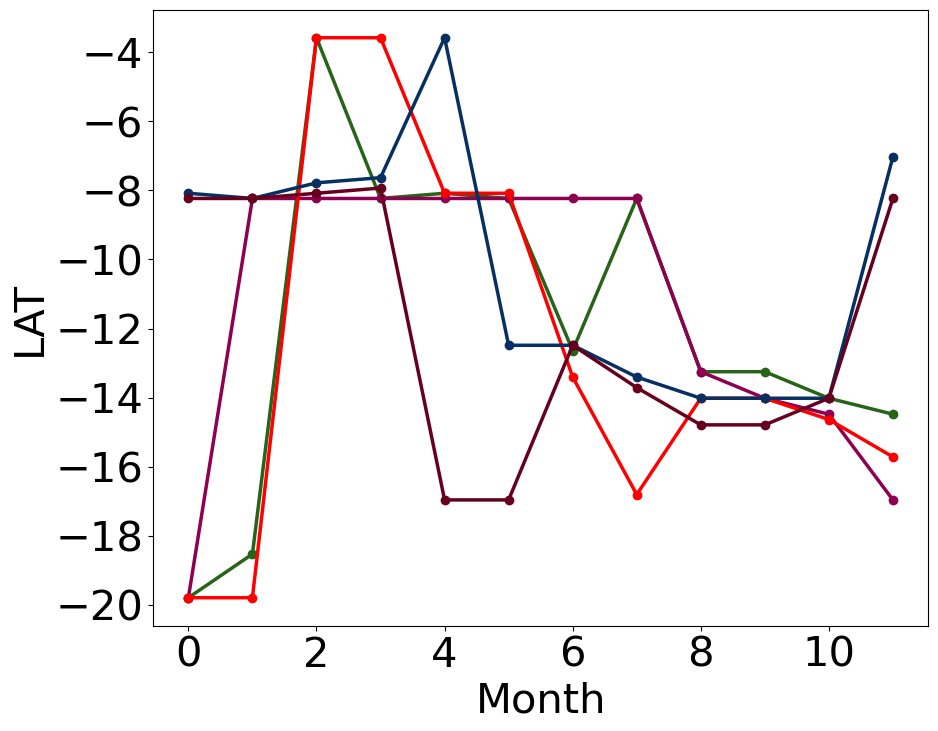

In [190]:
import datetime
fig = plt.figure(figsize=(10,8))

# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left_1 = cmap(0.0)
right_1 = cmap(1.0)

cmap = matplotlib.cm.get_cmap('RdBu')
left_2 = cmap(0.0)
right_2 = cmap(1.0)

#fig.suptitle('Amazon Precipitation', size=30)
plt.plot(sam_ctl_lati, color=right_1,marker='o',label="CTL",linewidth=2.5)
plt.plot(sam_p4k_lati, color=left_1,marker='o',label="P4K",linewidth=2.5)
plt.plot(sam_4co2_lati, color='red',marker='o',label="4CO2",linewidth=2.5)
plt.plot(sam_ngcb_lati, color=right_2,marker='o',label="NGCB",linewidth=2.5)
plt.plot(sam_ngce_lati, color=left_2,marker='o',label="NGCE",linewidth=2.5)
#plt.plot(sam2_lati,'o-g',label="CTL2",linewidth=2.5)

plt.ylabel('LAT',fontsize=30)
plt.xlabel('Month',fontsize=30)
#plt.xlim([datetime.date(2020, 1, 23),datetime.date(2021, 1, 31)])
#plt.ylim(0,25)
plt.xticks(fontsize=30,rotation=0)
plt.yticks(fontsize=30)
#plt.legend(fontsize=20, frameon=False, loc='center right')

(array([-80., -75., -70., -65., -60., -55., -50., -45., -40., -35., -30.]),
 [Text(0, -80.0, '−80'),
  Text(0, -75.0, '−75'),
  Text(0, -70.0, '−70'),
  Text(0, -65.0, '−65'),
  Text(0, -60.0, '−60'),
  Text(0, -55.0, '−55'),
  Text(0, -50.0, '−50'),
  Text(0, -45.0, '−45'),
  Text(0, -40.0, '−40'),
  Text(0, -35.0, '−35'),
  Text(0, -30.0, '−30')])

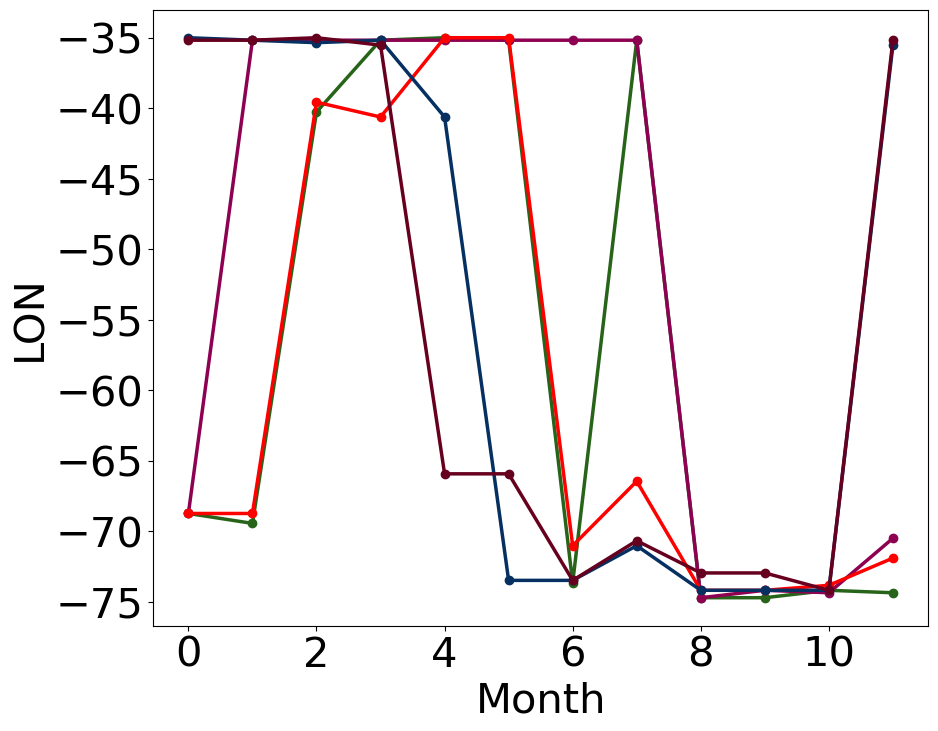

In [160]:
import datetime
fig = plt.figure(figsize=(10,8))

# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left_1 = cmap(0.0)
right_1 = cmap(1.0)

cmap = matplotlib.cm.get_cmap('RdBu')
left_2 = cmap(0.0)
right_2 = cmap(1.0)

#fig.suptitle('Amazon Precipitation', size=30)
plt.plot(sam_ctl_loni, color=right_1,marker='o',label="CTL",linewidth=2.5)
plt.plot(sam_p4k_loni, color=left_1,marker='o',label="P4K",linewidth=2.5)
plt.plot(sam_4co2_loni, color='red',marker='o',label="4CO2",linewidth=2.5)
plt.plot(sam_ngcb_loni, color=right_2,marker='o',label="NGCB",linewidth=2.5)
plt.plot(sam_ngce_loni, color=left_2,marker='o',label="NGCE",linewidth=2.5)
#plt.plot(sam2_loni,'o-g',label="CTL2",linewidth=2.5)

plt.ylabel('LON',fontsize=30)
plt.xlabel('Month',fontsize=30)
#plt.xlim([datetime.date(2020, 1, 23),datetime.date(2021, 1, 31)])
#plt.ylim(0,25)
plt.xticks(fontsize=30,rotation=0)
plt.yticks(fontsize=30)
#plt.legend(fontsize=20, frameon=False, loc='center right')

(array([ 4.,  6.,  8., 10., 12., 14., 16., 18., 20.]),
 [Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14'),
  Text(0, 16.0, '16'),
  Text(0, 18.0, '18'),
  Text(0, 20.0, '20')])

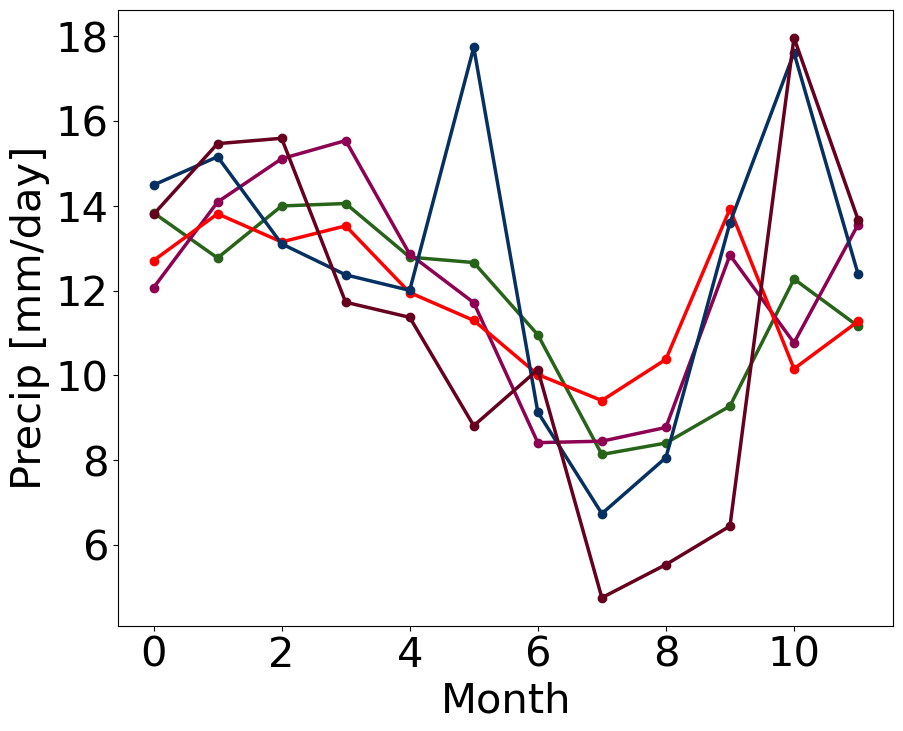

In [161]:
import datetime
fig = plt.figure(figsize=(10,8))

# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left_1 = cmap(0.0)
right_1 = cmap(1.0)

cmap = matplotlib.cm.get_cmap('RdBu')
left_2 = cmap(0.0)
right_2 = cmap(1.0)

#fig.suptitle('Amazon Precipitation', size=30)
plt.plot(sam_ctl_precip, color=right_1,marker='o',label="CTL",linewidth=2.5)
plt.plot(sam_p4k_precip, color=left_1,marker='o',label="P4K",linewidth=2.5)
plt.plot(sam_4co2_precip, color='red',marker='o',label="4CO2",linewidth=2.5)
plt.plot(sam_ngcb_precip, color=right_2,marker='o',label="NGCB",linewidth=2.5)
plt.plot(sam_ngce_precip, color=left_2,marker='o',label="NGCE",linewidth=2.5)
#plt.plot(sam2_precip,'o-g',label="CTL2",linewidth=2.5)

plt.ylabel('Precip [mm/day]',fontsize=30)
plt.xlabel('Month',fontsize=30)
#plt.xlim([datetime.date(2020, 1, 23),datetime.date(2021, 1, 31)])
#plt.ylim(0,25)
plt.xticks(fontsize=30,rotation=0)
plt.yticks(fontsize=30)
#plt.legend(fontsize=20, frameon=False, loc='center right')

(array([ 50., 100., 150., 200., 250., 300., 350., 400., 450., 500., 550.]),
 [Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250'),
  Text(0, 300.0, '300'),
  Text(0, 350.0, '350'),
  Text(0, 400.0, '400'),
  Text(0, 450.0, '450'),
  Text(0, 500.0, '500'),
  Text(0, 550.0, '550')])

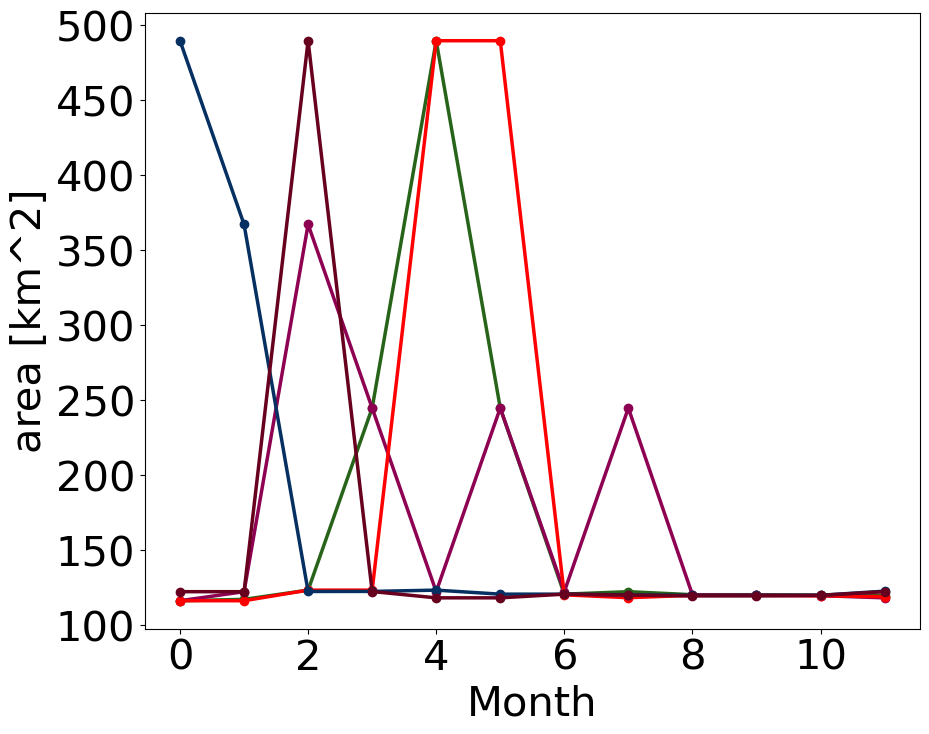

In [162]:
import datetime
fig = plt.figure(figsize=(10,8))

# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left_1 = cmap(0.0)
right_1 = cmap(1.0)

cmap = matplotlib.cm.get_cmap('RdBu')
left_2 = cmap(0.0)
right_2 = cmap(1.0)

#fig.suptitle('Amazon area', size=30)
plt.plot(np.concatenate(sam_ctl_area)/1000000, color=right_1,marker='o',label="CTL",linewidth=2.5)
plt.plot(np.concatenate(sam_p4k_area)/1000000, color=left_1,marker='o',label="P4K",linewidth=2.5)
plt.plot(np.concatenate(sam_4co2_area)/1000000, color='red',marker='o',label="4CO2",linewidth=2.5)
plt.plot(np.concatenate(sam_ngcb_area)/1000000, color=right_2,marker='o',label="NGCB",linewidth=2.5)
plt.plot(np.concatenate(sam_ngce_area)/1000000, color=left_2,marker='o',label="NGCE",linewidth=2.5)
#plt.plot(sam2_area,'o-g',label="CTL2",linewidth=2.5)

plt.ylabel('area [km^2]',fontsize=30)
plt.xlabel('Month',fontsize=30)
#plt.xlim([datetime.date(2020, 1, 23),datetime.date(2021, 1, 31)])
#plt.ylim(0,25)
plt.xticks(fontsize=30,rotation=0)
plt.yticks(fontsize=30)
#plt.legend(fontsize=20, frameon=False, loc='center right')

(array([0.0e+00, 2.0e-08, 4.0e-08, 6.0e-08, 8.0e-08, 1.0e-07, 1.2e-07,
        1.4e-07, 1.6e-07]),
 [Text(0, 0.0, '0.0'),
  Text(0, 2e-08, '0.2'),
  Text(0, 4e-08, '0.4'),
  Text(0, 6.000000000000001e-08, '0.6'),
  Text(0, 8e-08, '0.8'),
  Text(0, 1e-07, '1.0'),
  Text(0, 1.2000000000000002e-07, '1.2'),
  Text(0, 1.4e-07, '1.4'),
  Text(0, 1.6e-07, '1.6')])

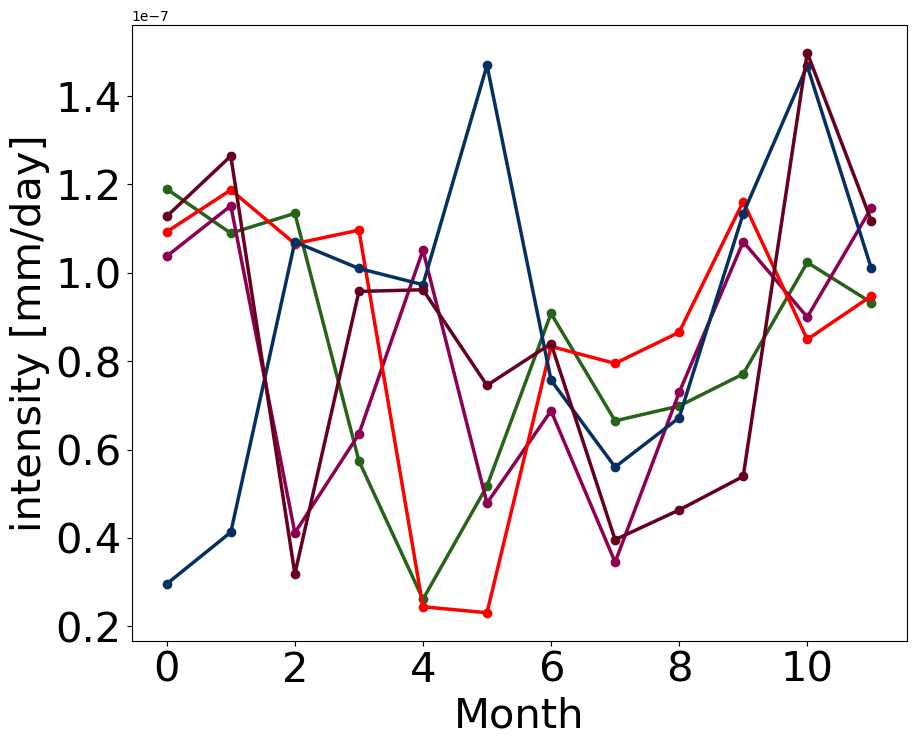

In [163]:
import datetime
fig = plt.figure(figsize=(10,8))

# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left_1 = cmap(0.0)
right_1 = cmap(1.0)

cmap = matplotlib.cm.get_cmap('RdBu')
left_2 = cmap(0.0)
right_2 = cmap(1.0)

#fig.suptitle('Amazon intensityitation', size=30)
plt.plot(sam_ctl_intensity, color=right_1,marker='o',label="CTL",linewidth=2.5)
plt.plot(sam_p4k_intensity, color=left_1,marker='o',label="P4K",linewidth=2.5)
plt.plot(sam_4co2_intensity, color='red',marker='o',label="4CO2",linewidth=2.5)
plt.plot(sam_ngcb_intensity, color=right_2,marker='o',label="NGCB",linewidth=2.5)
plt.plot(sam_ngce_intensity, color=left_2,marker='o',label="NGCE",linewidth=2.5)
#plt.plot(sam2_intensity,'o-g',label="CTL2",linewidth=2.5)

plt.ylabel('intensity [mm/day]',fontsize=30)
plt.xlabel('Month',fontsize=30)
#plt.xlim([datetime.date(2020, 1, 23),datetime.date(2021, 1, 31)])
#plt.ylim(0,25)
plt.xticks(fontsize=30,rotation=0)
plt.yticks(fontsize=30)
#plt.legend(fontsize=20, frameon=False, loc='center right')

In [192]:
def obj_pr(ctl_loni, ctl_lati, p4k_loni, p4k_lati, co2_loni, co2_lati, lat_min, lat_max, lon_min, lon_max):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    
    proj = ccrs.PlateCarree(central_longitude=180) # Create Mollweide projections
    fig  = plt.figure(figsize=(8, 10))
    ax = fig.add_subplot(111, projection=proj)
    
    minlon = lon_min + 5 + 180 #on
    maxlon = lon_max - 5 + 180 #on
    
    ax.set_extent([minlon,maxlon,lat_min+5,lat_max-5],proj) #on
    ax.coastlines(resolution='50m', linewidth=1.5, color='black')
    
    # gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                        xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False
    
    kw = {'levels':[-1], 'colors':['gray'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      linewidth=0.5,
                      **kw
                     )
    colors_r = ['#FFEBEB', '#FFD7D7', '#FFC3C3', '#FFAFAF', '#FF9B9B', '#FF7373', '#FF4B4B', '#FF1919', '#F00000', '#C80000', '#A00000', '#640000'] 
    colors_b = ['#E1F6FF', '#CDF0FF', '#B9EBFF', '#A5E5FF', '#91E0FF', '#73D7FF', '#55CEFF', '#37C6FF', '#19BDFF', '#00ABF0', '#0072A0', '#004764']
    colors_g = ['#E9F7F5', '#DAF2EF', '#CCECE7', '#BDE7E0', '#AEE2D9', '#91CDCB', '#74CCBD', '#55C3B1', '#3FB19E', '#359383', '#226056', '#153B35']
    
    # Same as Hans' color map
    colors_default = ['navy', 'navy', 'teal', 'teal', 'darkgreen', 'darkgreen', 'orange', 'orange', 'red', 'red', 'brown', 'brown'] 
    
    colors_r_ss = ['#FFAA00', '#FF8800', '#FF6600', '#FF4400', '#F22000',  '#FF0000'] 
    colors_b_ss = ['#33FFFF', '#33DDFF', '#33AAFF', '#3377FF', '#3355FF',  '#3300FF']
    colors_g_ss = ['#00FF11', '#00DD11', '#00BB11', '#008811', '#006611',  '#003311']
    
    #plt.plot(ctl_loni, ctl_lati, transform=ccrs.PlateCarree(), color='cornflowerblue',ls='-')
    #plt.plot(def_loni, def_lati, transform=ccrs.PlateCarree(), color='pink', ls='--')
    #plt.plot(imerg_loni, imerg_lati, transform=ccrs.PlateCarree(), color='yellowgreen')
    
  #  plt.plot(ctl_loni, ctl_lati, transform=ccrs.PlateCarree(), color='black',ls='-', linewidth=2)
  #  plt.plot(p4k_loni, p4k_lati, transform=ccrs.PlateCarree(), color='black', ls='--', linewidth=2)
  #  plt.plot(co2_loni, co2_lati, transform=ccrs.PlateCarree(), color='black', ls='--', linewidth=2)
    
    for i in range(12):
        plt.scatter(x=ctl_loni[i], y=ctl_lati[i],transform=ccrs.PlateCarree(), facecolors='none', edgecolors=colors_b[i], marker='o', s=400, linewidth=2) #colors_b[i]
        plt.scatter(x=p4k_loni[i], y=p4k_lati[i],transform=ccrs.PlateCarree(), facecolors='none', edgecolors=colors_r[i], marker='s', s=400, linewidth=2) #colors_r[i]
        plt.scatter(x=co2_loni[i], y=co2_lati[i],transform=ccrs.PlateCarree(), facecolors='none', edgecolors=colors_g[i], marker='^', s=400, linewidth=2) #colors_r[i]
        #plt.errorbar(x=imerg_loni[i], y=imerg_lati[i], xerr=imerg_loni_std[i], yerr=imerg_lati_std[i], transform=ccrs.PlateCarree(), color='#555555')
        #plt.scatter(x=imerg_loni[i], y=imerg_lati[i],transform=ccrs.PlateCarree(), color=colors_g[i], marker="^", s=200) #colors_g
        
    #fig.savefig('./obj_precip_wo_basin.png', transparent=True)

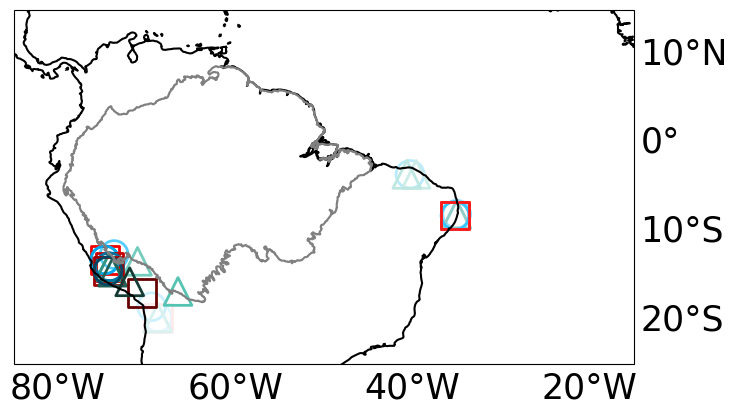

In [193]:
obj_pr(sam_ctl_loni, sam_ctl_lati, sam_p4k_loni, sam_p4k_lati, sam_4co2_loni, sam_4co2_lati, -30, 20, -90, -10)

In [169]:
def obj_pr(ctl_loni, ctl_lati, p4k_loni, p4k_lati,lat_min, lat_max, lon_min, lon_max):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    
    proj = ccrs.PlateCarree(central_longitude=180) # Create Mollweide projections
    fig  = plt.figure(figsize=(8, 10))
    ax = fig.add_subplot(111, projection=proj)
    
    minlon = lon_min + 5 + 180 #on
    maxlon = lon_max - 5 + 180 #on
    
    ax.set_extent([minlon,maxlon,lat_min+5,lat_max-5],proj) #on
    ax.coastlines(resolution='50m', linewidth=1.5, color='black')
    
    # gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                        xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False
    
    kw = {'levels':[-1], 'colors':['gray'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      linewidth=0.5,
                      **kw
                     )
    colors_r = ['#FFEBEB', '#FFD7D7', '#FFC3C3', '#FFAFAF', '#FF9B9B', '#FF7373', '#FF4B4B', '#FF1919', '#F00000', '#C80000', '#A00000', '#640000'] 
    colors_b = ['#E1F6FF', '#CDF0FF', '#B9EBFF', '#A5E5FF', '#91E0FF', '#73D7FF', '#55CEFF', '#37C6FF', '#19BDFF', '#00ABF0', '#0072A0', '#004764']
    colors_g = ['#E9F7F5', '#DAF2EF', '#CCECE7', '#BDE7E0', '#AEE2D9', '#91CDCB', '#74CCBD', '#55C3B1', '#3FB19E', '#359383', '#226056', '#153B35']
    
    # Same as Hans' color map
    colors_default = ['navy', 'navy', 'teal', 'teal', 'darkgreen', 'darkgreen', 'orange', 'orange', 'red', 'red', 'brown', 'brown'] 
    
    colors_r_ss = ['#FFAA00', '#FF8800', '#FF6600', '#FF4400', '#F22000',  '#FF0000'] 
    colors_b_ss = ['#33FFFF', '#33DDFF', '#33AAFF', '#3377FF', '#3355FF',  '#3300FF']
    colors_g_ss = ['#00FF11', '#00DD11', '#00BB11', '#008811', '#006611',  '#003311']
    
    #plt.plot(ctl_loni, ctl_lati, transform=ccrs.PlateCarree(), color='cornflowerblue',ls='-')
    #plt.plot(def_loni, def_lati, transform=ccrs.PlateCarree(), color='pink', ls='--')
    #plt.plot(imerg_loni, imerg_lati, transform=ccrs.PlateCarree(), color='yellowgreen')
    
  #  plt.plot(ctl_loni, ctl_lati, transform=ccrs.PlateCarree(), color='black',ls='-', linewidth=2)
  #  plt.plot(p4k_loni, p4k_lati, transform=ccrs.PlateCarree(), color='black', ls='--', linewidth=2)
  #  plt.plot(co2_loni, co2_lati, transform=ccrs.PlateCarree(), color='black', ls='--', linewidth=2)
    
    for i in range(12):
        plt.scatter(x=ctl_loni[i], y=ctl_lati[i],transform=ccrs.PlateCarree(), facecolors='none', edgecolors=colors_b[i], marker='o', s=400, linewidth=2) #colors_b[i]
        plt.scatter(x=p4k_loni[i], y=p4k_lati[i],transform=ccrs.PlateCarree(), facecolors='none', edgecolors=colors_r[i], marker='s', s=400, linewidth=2) #colors_r[i]
        #plt.errorbar(x=imerg_loni[i], y=imerg_lati[i], xerr=imerg_loni_std[i], yerr=imerg_lati_std[i], transform=ccrs.PlateCarree(), color='#555555')
        #plt.scatter(x=imerg_loni[i], y=imerg_lati[i],transform=ccrs.PlateCarree(), color=colors_g[i], marker="^", s=200) #colors_g
        
    #fig.savefig('./obj_precip_wo_basin.png', transparent=True)

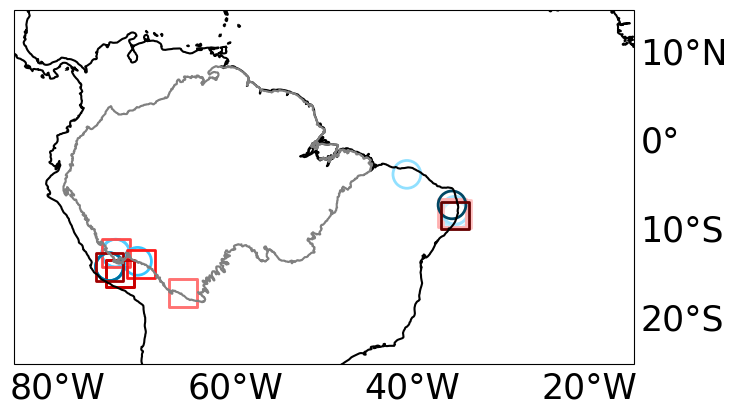

In [170]:
obj_pr(sam_ngcb_loni, sam_ngcb_lati, sam_ngce_loni, sam_ngce_lati, -30, 20, -90, -10)